# Dataset Exploration
**Dataset:** `sales_with_converted_rents_enriched_with_arbk.xlsx`

This notebook analyzes:
1. Data types
2. Null and non-null values
3. Data quality (duplicate rows, ARBK match rate, cardinality)

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 80
plt.rcParams['font.size'] = 10

In [38]:
FILE = '../data/raw/sales_with_converted_rents_enriched_with_arbk.xlsx'

df = pd.read_excel(FILE, engine='openpyxl')

print(f'Rows   : {len(df)}')
print(f'Columns: {len(df.columns)}')

Rows   : 3483
Columns: 47


---
## 1. Data Types

In [39]:
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values.astype(str)
})

dtype_df['Category'] = dtype_df['Type'].map(lambda t:
    'Numeric' if t.startswith(('int', 'float')) else
    'Date/Time' if t.startswith('datetime') else
    'Text/Object'
)

print('Type distribution:')
print(dtype_df['Category'].value_counts().to_string())
print()
print(dtype_df.to_string(index=False))

Type distribution:
Category
Text/Object    34
Numeric        12
Date/Time       1

                                                                Column           Type    Category
                                                                   Nr.          int64     Numeric
                                                            Rajoni AKP            str Text/Object
                                                                PAK ID            str Text/Object
                                                  Ndërmarrja Shoqërore            str Text/Object
                       Emri i Ndërmarrjes së Re apo Asetit në Likuidim            str Text/Object
                                                    Kategoria e asetit            str Text/Object
                                                      Mënyra e shitjes            str Text/Object
Sipërfaqja e objektit NëSE KA OBJEKT TE TOKA DHE DIHET SIPERFAQJA [m2]        float64     Numeric
                                   

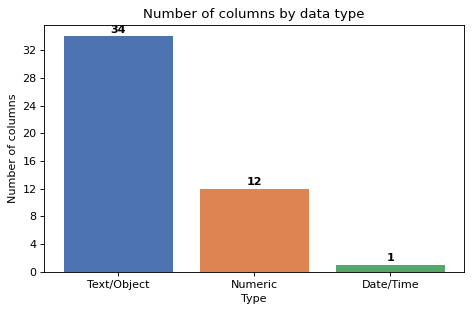

In [40]:
counts = dtype_df['Category'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452', '#55A868'])

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontweight='bold'
    )

ax.set_title('Number of columns by data type')
ax.set_ylabel('Number of columns')
ax.set_xlabel('Type')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

---
## 2. Null and Non-Null Values

In [41]:
null_counts = df.isnull().sum()
notnull_counts = df.notnull().sum()
total = len(df)

null_df = pd.DataFrame({
    'Column': df.columns,
    'Non-Null': notnull_counts.values,
    'Null': null_counts.values,
    '% Null': (null_counts.values / total * 100).round(2)
})

null_df = null_df.sort_values('% Null', ascending=False).reset_index(drop=True)

print(f'Total rows: {total}')
print()
print(null_df.to_string(index=False))

Total rows: 3483

                                                                Column  Non-Null  Null  % Null
                                                         ARBK_WebFaqja        15  3468   99.57
                                             ARBK_DataShuarjesBiznesit       378  3105   89.15
                                                            ARBK_Email       460  3023   86.79
                                    ARBK_Aktiviteti_5_LlojiAktivitetit       886  2597   74.56
                                            ARBK_Aktiviteti_5_KodiNace       886  2597   74.56
                                          ARBK_Aktiviteti_5_Pershkrimi       886  2597   74.56
                                          ARBK_Aktiviteti_4_Pershkrimi      1104  2379   68.30
                                    ARBK_Aktiviteti_4_LlojiAktivitetit      1104  2379   68.30
                                            ARBK_Aktiviteti_4_KodiNace      1104  2379   68.30
                                

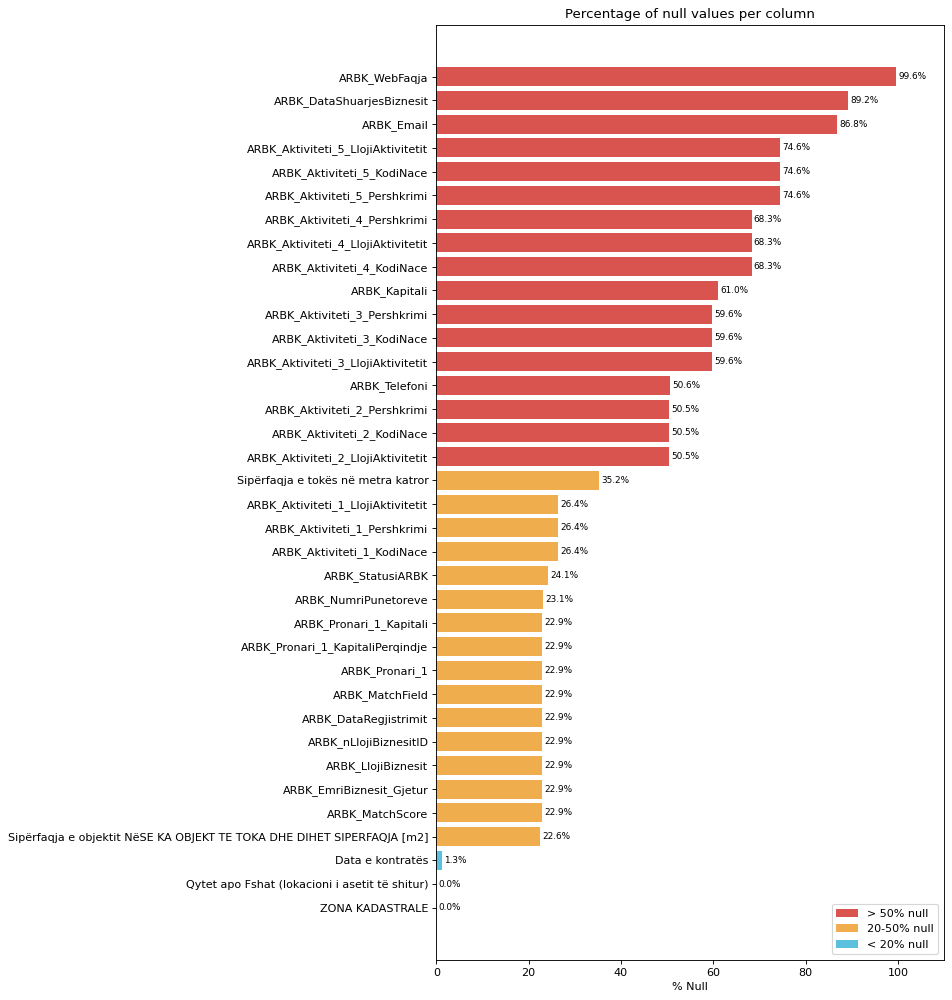

In [42]:
cols_with_nulls = null_df[null_df['Null'] > 0].copy()

if len(cols_with_nulls) == 0:
    print('No null values found in the dataset.')
else:
    fig, ax = plt.subplots(figsize=(12, max(4, len(cols_with_nulls) * 0.35)))

    colors = ['#d9534f' if p > 50 else '#f0ad4e' if p > 20 else '#5bc0de'
              for p in cols_with_nulls['% Null']]

    bars = ax.barh(cols_with_nulls['Column'], cols_with_nulls['% Null'], color=colors)

    for bar, val in zip(bars, cols_with_nulls['% Null']):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            va='center', fontsize=8
        )

    ax.set_xlabel('% Null')
    ax.set_title('Percentage of null values per column')
    ax.set_xlim(0, 110)
    ax.invert_yaxis()

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#d9534f', label='> 50% null'),
        Patch(facecolor='#f0ad4e', label='20-50% null'),
        Patch(facecolor='#5bc0de', label='< 20% null'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.show()

---
## 3. Data Quality

### 3.1 Duplicate Rows

In [43]:
total_dups = df.duplicated().sum()
unique_rows = len(df) - total_dups

print(f'Total rows      : {len(df)}')
print(f'Unique rows     : {unique_rows}')
print(f'Duplicate rows  : {total_dups} ({total_dups / len(df) * 100:.2f}%)')

if total_dups > 0:
    print()
    print('Duplicate rows:')
    print(df[df.duplicated(keep=False)].to_string())

Total rows      : 3483
Unique rows     : 3483
Duplicate rows  : 0 (0.00%)


### 3.2 ARBK Match Rate

In [52]:
if 'ARBK_MatchField' not in df.columns:
    print('Column ARBK_MatchField not found in dataset.')
else:
    matched = df['ARBK_MatchField'].notna() & (df['ARBK_MatchField'] != '')
    n_matched = matched.sum()
    n_unmatched = (~matched).sum()
    total = len(df)

    print(f'Total rows           : {total}')
    print(f'Matched with ARBK    : {n_matched} ({n_matched / total * 100:.1f}%)')
    print(f'Not matched          : {n_unmatched} ({n_unmatched / total * 100:.1f}%)')


Total rows           : 3483
Matched with ARBK    : 2687 (77.1%)
Not matched          : 796 (22.9%)


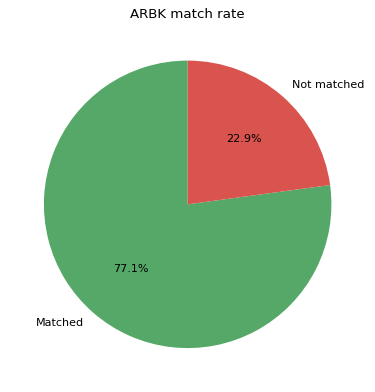

In [48]:
if 'ARBK_MatchField' in df.columns:
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.pie(
        [n_matched, n_unmatched],
        labels=['Matched', 'Not matched'],
        colors=['#55A868', '#d9534f'],
        autopct='%1.1f%%',
        startangle=90
    )
    ax.set_title('ARBK match rate')

    plt.tight_layout()
    plt.show()

### 3.3 Cardinality of Categorical Columns

In [49]:
obj_cols = df.select_dtypes(include='object').columns.tolist()

card_df = pd.DataFrame({
    'Column': obj_cols,
    'Unique Values': [df[c].nunique() for c in obj_cols],
    '% Unique': [round(df[c].nunique() / len(df) * 100, 2) for c in obj_cols]
}).sort_values('Unique Values', ascending=False).reset_index(drop=True)

print(card_df.to_string(index=False))

                                               Column  Unique Values  % Unique
                                              Blerësi           2976     85.44
      Emri i Ndërmarrjes së Re apo Asetit në Likuidim           2662     76.43
                             ARBK_EmriBiznesit_Gjetur           2106     60.47
                                       ARBK_Pronari_1           2084     59.83
                                ARBK_DataRegjistrimit           1541     44.24
                                               PAK ID           1541     44.24
                                        ARBK_Telefoni           1358     38.99
                                      ZONA KADASTRALE            812     23.31
                                 Ndërmarrja Shoqërore            693     19.90
                                           ARBK_Email            367     10.54
                            ARBK_DataShuarjesBiznesit            299      8.58
                                     ARBK_StatusiARB

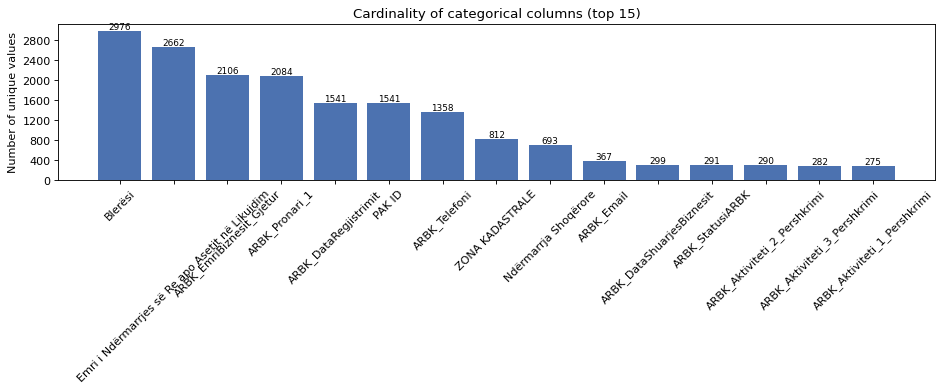

In [50]:
top_card = card_df.head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_card['Column'], top_card['Unique Values'], color='#4C72B0')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=8
    )

ax.set_title('Cardinality of categorical columns (top 15)')
ax.set_ylabel('Number of unique values')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [31]:
low_card = card_df[card_df['Unique Values'] <= 20]['Column'].tolist()

print(f'Low-cardinality columns (<= 20 unique values): {len(low_card)}')
print()

for col in low_card:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).head(10).to_string())
    print()

Low-cardinality columns (<= 20 unique values): 12

--- ARBK_WebFaqja ---
ARBK_WebFaqja
NaN                                        3468
https://petrolcompany.biz/sq/Fillimi          4
www.elkosgroup.com                            2
www.elsamks.com                               1
www.pishina-ks                                1
ux-devs.com                                   1
www.gazetaenigma.com                          1
https://www.facebook.com/grannit.ademaj       1
https://shpedicionivjosa.business.site/       1
WWWascom-group.com                            1

--- Rajoni AKP ---
Rajoni AKP
Prishtina    1405
Peja          666
Mitrovica     455
Prizren       418
Gjilan        375
Prizreni       69
AD             69
Gjilani        26

--- Mënyra e shitjes ---
Mënyra e shitjes
spin off i rregullt                             1881
aset në likuidim                                 733
Aset në likuidim                                 479
negociata direkte - ndërtime                     280
neg

## Price of land without Plot

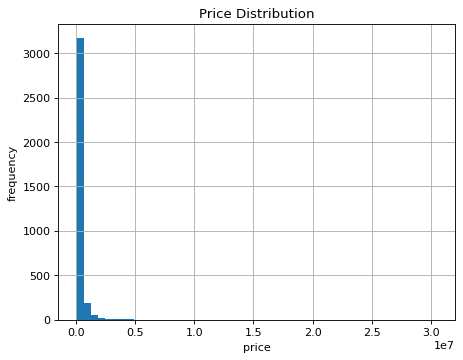

In [32]:
df['Cmimi i shitjes së asetit'].hist(bins=50)
# print(df['Cmimi i shitjes së asetit'])
plt.xlabel('price')
plt.ylabel('frequency')
plt.title('Price Distribution')
plt.show()


## Price distribution after log application

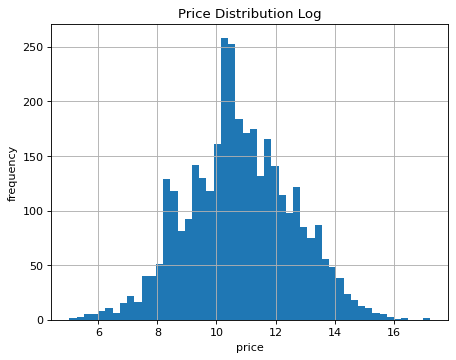

In [43]:
np.log1p(df['Cmimi i shitjes së asetit']).hist(bins=50)
# print(df['Cmimi i shitjes së asetit'])
plt.xlabel('price')
plt.ylabel('frequency')
plt.title('Price Distribution Log')
plt.show()

## Square meters of land

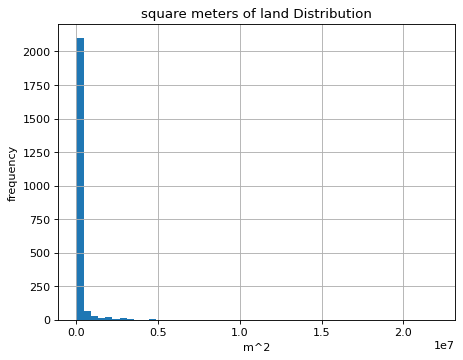

In [36]:
df['Sipërfaqja e tokës në metra katror'].hist(bins=50)
# print(df['Cmimi i shitjes së asetit'])
plt.xlabel('m^2')
plt.ylabel('frequency')
plt.title('square meters of land Distribution')
plt.show()

## Square meters of land after log application

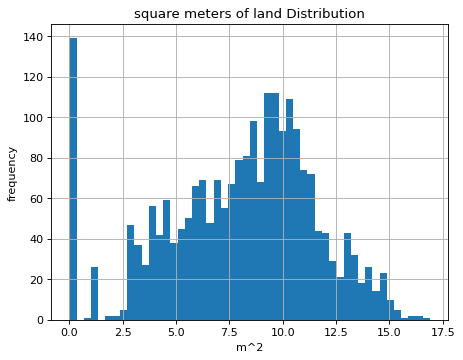

In [37]:
np.log1p(df['Sipërfaqja e tokës në metra katror']).hist(bins=50)
# print(df['Cmimi i shitjes së asetit'])
plt.xlabel('m^2')
plt.ylabel('frequency')
plt.title('square meters of land Distribution')
plt.show()

## Square meters of Objects when applicable

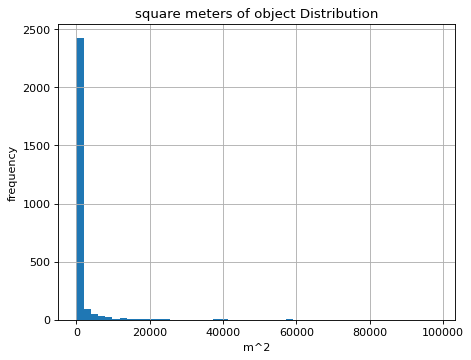

In [39]:
df['Sipërfaqja e objektit NëSE KA OBJEKT TE TOKA DHE DIHET SIPERFAQJA [m2]'].hist(bins=50)
# print(df['Cmimi i shitjes së asetit'])
plt.xlabel('m^2')
plt.ylabel('frequency')
plt.title('square meters of object Distribution')
plt.show()

## Square meters of Objects when applicable Log applied

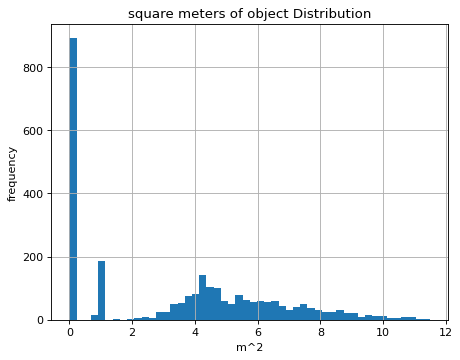

In [38]:
np.log1p(df['Sipërfaqja e objektit NëSE KA OBJEKT TE TOKA DHE DIHET SIPERFAQJA [m2]']).hist(bins=50)
# print(df['Cmimi i shitjes së asetit'])
plt.xlabel('m^2')
plt.ylabel('frequency')
plt.title('square meters of object Distribution')
plt.show()

## square meters of object + land plot

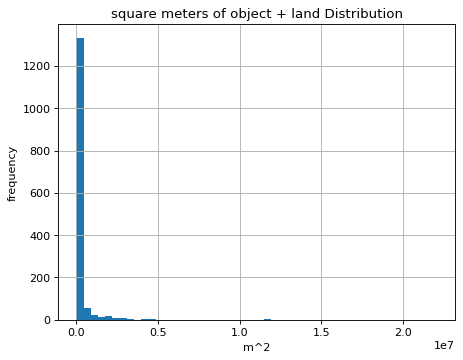

In [41]:
(df['Sipërfaqja e objektit NëSE KA OBJEKT TE TOKA DHE DIHET SIPERFAQJA [m2]'] + df['Sipërfaqja e tokës në metra katror']).hist(bins=50)
# print(df['Cmimi i shitjes së asetit'])
plt.xlabel('m^2')
plt.ylabel('frequency')
plt.title('square meters of object + land Distribution')
plt.show()

## square meters of object + land plot

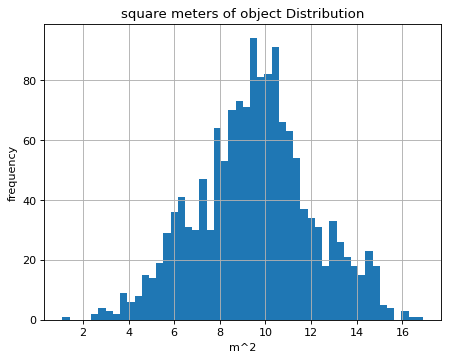

In [ ]:
np.log1p(df['Sipërfaqja e objektit NëSE KA OBJEKT TE TOKA DHE DIHET SIPERFAQJA [m2]'] + df['Sipërfaqja e tokës në metra katror']).hist(bins=50)
# print(df['Cmimi i shitjes së asetit'])
plt.xlabel('m^2')
plt.ylabel('frequency')
plt.title('square meters of object + land Distribution Log')
plt.show()